This notebook focuses on trying to find a way to segment cells within organoids properly.
The end goals is to segment cell and extract morphology features from cellprofiler.
These masks must be imported into cellprofiler to extract features.

In [1]:
import argparse
import pathlib
import sys

import matplotlib.pyplot as plt

# Import dependencies
import numpy as np
import skimage
import tifffile
from cellpose import core
from cellpose import io as cellpose_io
from cellpose import models

cellpose_io.logger_setup()
import torch
from cellpose.io import imread
from PIL import Image
from skimage import io

use_GPU = torch.cuda.is_available()

# set import path
sys.path.append(str(pathlib.Path("../../utils/").resolve()))

# check if in a jupyter notebook
try:
    cfg = get_ipython().config
    in_notebook = True
except NameError:
    in_notebook = False

print(in_notebook)

2025-01-09 14:12:22,535 [INFO] WRITING LOG OUTPUT TO /home/lippincm/.cellpose/run.log
2025-01-09 14:12:22,536 [INFO] 
cellpose version: 	3.1.0 
platform:       	linux 
python version: 	3.9.21 
torch version:  	2.5.1+cu124
True


In [2]:
if not in_notebook:
    # set up arg parser
    parser = argparse.ArgumentParser(description="Segment the nuclei of a tiff image")

    parser.add_argument(
        "--input_dir",
        type=str,
        help="Path to the input directory containing the tiff images",
    )
    parser.add_argument(
        "--window_size", type=int, help="Size of the window to use for the segmentation"
    )
    parser.add_argument(
        "--clip_limit",
        type=float,
        help="Clip limit for the adaptive histogram equalization",
    )

    args = parser.parse_args()
    window_size = args.window_size
    clip_limit = args.clip_limit
    input_dir = pathlib.Path(args.input_dir).resolve(strict=True)

else:
    input_dir = pathlib.Path("../../data/z-stack_images/C4-2/").resolve(strict=True)
    window_size = 3
    clip_limit = 0.1

mask_path = pathlib.Path(f"../processed_data/{input_dir.stem}").resolve()
mask_path.mkdir(exist_ok=True, parents=True)

## Set up images, paths and functions

In [3]:
image_extensions = {".tif", ".tiff"}
files = sorted(input_dir.glob("*"))
files = [str(x) for x in files if x.suffix in image_extensions]

In [4]:
# find the cytoplasmic channels in the image set
for f in files:
    if "405" in f:
        nuclei = io.imread(f)
    elif "488" in f:
        cyto1 = io.imread(f)
    elif "555" in f:
        cyto2 = io.imread(f)
    elif "640" in f:
        cyto3 = io.imread(f)
    else:
        print(f"Unknown channel: {f}")

# pick which channels to use for cellpose
cyto = skimage.exposure.equalize_adapthist(cyto2, clip_limit=clip_limit)


original_nuclei_image = nuclei.copy()
original_cyto_image = cyto.copy()

original_nuclei_z_count = nuclei.shape[0]
original_cyto_z_count = cyto.shape[0]

Unknown channel: /home/lippincm/Documents/GFF_3D_organoid_profiling_pipeline/data/z-stack_images/C4-2/C4-2_TRANS.tif


In [5]:
# make a 2.5 D max projection image stack with a sliding window of 3 slices
image_stack_2_5D = np.empty((0, cyto.shape[1], cyto.shape[2]), dtype=cyto.dtype)
for image_index in range(cyto.shape[0]):
    image_stack_window = cyto[image_index : image_index + window_size]
    if not image_stack_window.shape[0] == window_size:
        break
    # max project the image stack
    image_stack_2_5D = np.append(
        image_stack_2_5D, np.max(image_stack_window, axis=0)[np.newaxis, :, :], axis=0
    )

image_stack_2_5D = np.array(image_stack_2_5D)
cyto = np.array(image_stack_2_5D)
print("2.5D cyto image stack shape:", cyto.shape)


# make a 2.5 D max projection image stack with a sliding window of 3 slices
image_stack_2_5D = np.empty((0, nuclei.shape[1], nuclei.shape[2]), dtype=nuclei.dtype)
for image_index in range(nuclei.shape[0]):
    image_stack_window = nuclei[image_index : image_index + window_size]
    if not image_stack_window.shape[0] == window_size:
        break
    # max project the image stack
    image_stack_2_5D = np.append(
        image_stack_2_5D, np.max(image_stack_window, axis=0)[np.newaxis, :, :], axis=0
    )

nuclei = np.array(image_stack_2_5D)
print("2.5D nuclei image stack shape:", nuclei.shape)

2.5D cyto image stack shape: (31, 1537, 1540)
2.5D nuclei image stack shape: (31, 1537, 1540)


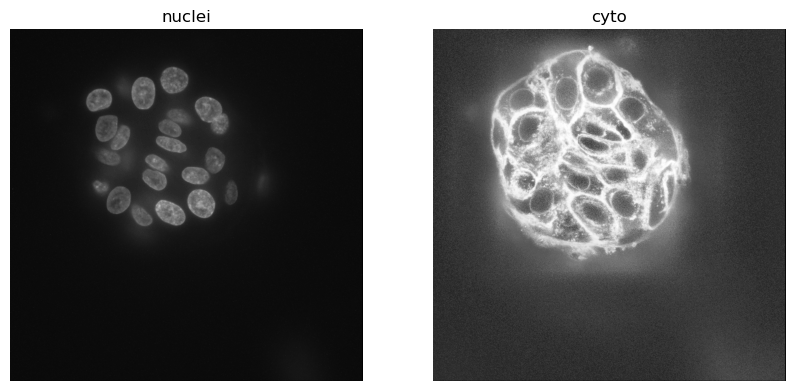

In [6]:
if in_notebook:
    # plot the nuclei and the cyto channels
    plt.figure(figsize=(10, 10))
    plt.subplot(121)
    plt.imshow(nuclei[9, :, :], cmap="gray")
    plt.title("nuclei")
    plt.axis("off")
    plt.subplot(122)
    plt.imshow(cyto[9, :, :], cmap="gray")
    plt.title("cyto")
    plt.axis("off")
    plt.show()

In [7]:
imgs = []
# save each z-slice as an RGB png
for z in range(nuclei.shape[0]):

    nuclei_tmp = nuclei[z, :, :]
    cyto_tmp = cyto[z, :, :]
    nuclei_tmp = (nuclei_tmp / nuclei_tmp.max() * 255).astype(np.uint8)
    cyto_tmp = (cyto_tmp / cyto_tmp.max() * 255).astype(np.uint8)
    # save the image as an RGB png with nuclei in blue and cytoplasm in red
    RGB = np.stack([cyto_tmp, np.zeros_like(cyto_tmp), nuclei_tmp], axis=-1)

    # change to 8-bit
    RGB = (RGB / RGB.max() * 255).astype(np.uint8)

    rgb_image_pil = Image.fromarray(RGB)

    imgs.append(rgb_image_pil)

## Cellpose

In [8]:
# model_type='cyto' or 'nuclei' or 'cyto2' or 'cyto3'
model_name = "cyto3"
model = models.Cellpose(model_type=model_name, gpu=use_GPU)

channels = [[1, 3]]  # channels=[red cells, blue nuclei]
diameter = 150

masks_all_dict = {"masks": [], "imgs": []}
imgs = np.array(imgs)

# get masks for all the images
# save to a dict for later use
for img in imgs:
    masks, flows, styles, diams = model.eval(img, diameter=diameter, channels=channels)
    masks_all_dict["masks"].append(masks)
    masks_all_dict["imgs"].append(img)
print(len(masks_all_dict))

2025-01-09 14:12:37,683 [INFO] ** TORCH CUDA version installed and working. **
2025-01-09 14:12:37,683 [INFO] >>>> using GPU (CUDA)
2025-01-09 14:12:37,684 [INFO] >> cyto3 << model set to be used
2025-01-09 14:12:37,749 [INFO] >>>> loading model /home/lippincm/.cellpose/models/cyto3
2025-01-09 14:12:37,839 [INFO] >>>> model diam_mean =  30.000 (ROIs rescaled to this size during training)


/home/lippincm/miniforge3/envs/GFF_cellpose/lib/python3.9/site-packages/cellpose/resnet_torch.py:271: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(f

2025-01-09 14:12:38,002 [INFO] channels set to [[1, 3]]
2025-01-09 14:12:38,003 [INFO] ~~~ FINDING MASKS ~~~
2025-01-09 14:12:40,243 [INFO] >>>> TOTAL TIME 2.24 sec
2025-01-09 14:12:40,244 [INFO] channels set to [[1, 3]]
2025-01-09 14:12:40,244 [INFO] ~~~ FINDING MASKS ~~~
2025-01-09 14:12:41,307 [INFO] >>>> TOTAL TIME 1.06 sec
2025-01-09 14:12:41,308 [INFO] channels set to [[1, 3]]
2025-01-09 14:12:41,308 [INFO] ~~~ FINDING MASKS ~~~
2025-01-09 14:12:42,198 [INFO] >>>> TOTAL TIME 0.89 sec
2025-01-09 14:12:42,198 [INFO] channels set to [[1, 3]]
2025-01-09 14:12:42,199 [INFO] ~~~ FINDING MASKS ~~~
2025-01-09 14:12:43,021 [INFO] >>>> TOTAL TIME 0.82 sec
2025-01-09 14:12:43,025 [INFO] channels set to [[1, 3]]
2025-01-09 14:12:43,025 [INFO] ~~~ FINDING MASKS ~~~
2025-01-09 14:12:43,875 [INFO] >>>> TOTAL TIME 0.85 sec
2025-01-09 14:12:43,876 [INFO] channels set to [[1, 3]]
2025-01-09 14:12:43,876 [INFO] ~~~ FINDING MASKS ~~~
2025-01-09 14:12:44,652 [INFO] >>>> TOTAL TIME 0.78 sec
2025-01-09

In [9]:
masks_all = masks_all_dict["masks"]
imgs = masks_all_dict["imgs"]

In [10]:
# reverse sliding window max projection
full_mask_z_stack = []
reconstruction_dict = {index: [] for index in range(original_cyto_z_count)}
print(f"Decoupling the sliding window max projection of {window_size} slices")

# decouple the sliding window max projection based on window size
# each slice in a stack
for z_stack_mask_index in range(len(masks_all)):
    # temoporary list to hold the decoupled z stack
    z_stack_decouple = []
    # decouple
    [z_stack_decouple.append(masks_all[z_stack_mask_index]) for _ in range(window_size)]
    # dull out the decouple slice to the correct z index
    for z_window_index, z_stack_mask in enumerate(z_stack_decouple):
        if not (z_stack_mask_index + z_window_index) >= original_cyto_z_count:
            reconstruction_dict[z_stack_mask_index + z_window_index].append(
                z_stack_mask
            )

# save the reconstruction_dict to a file for downstream decoupling
np.save(mask_path / "cell_reconstruction_dict.npy", reconstruction_dict)

Decoupling the sliding window max projection of 3 slices


<Figure size 1000x500 with 0 Axes>

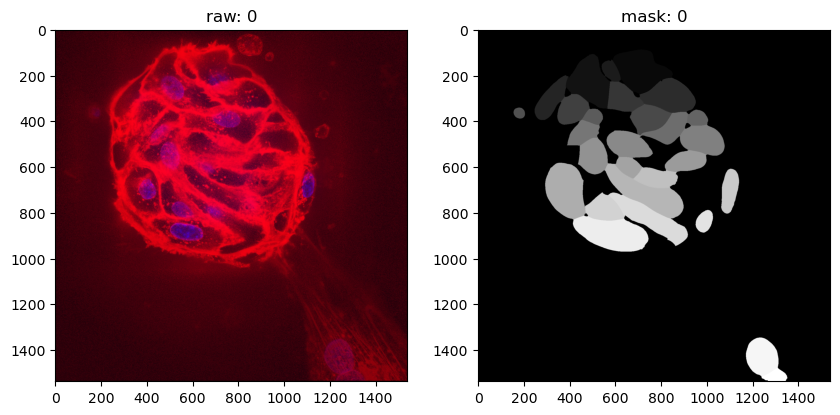

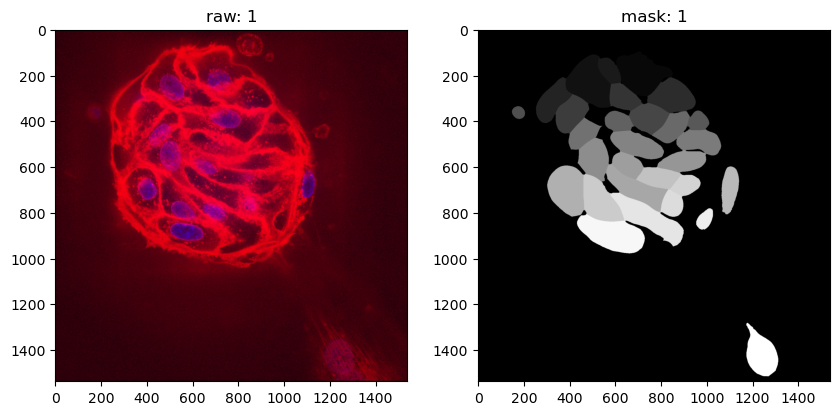

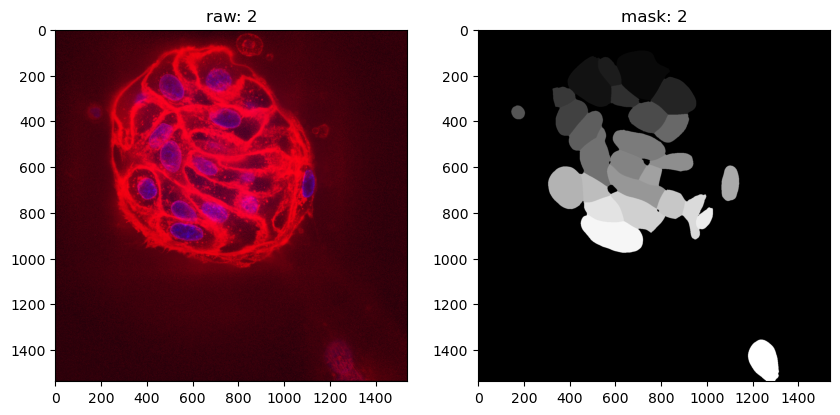

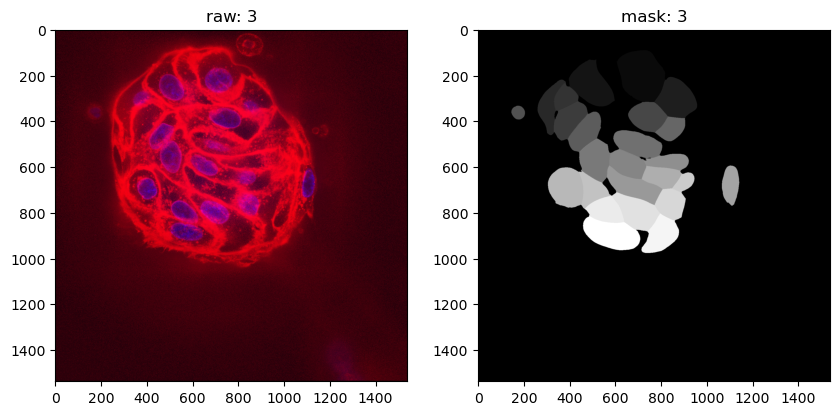

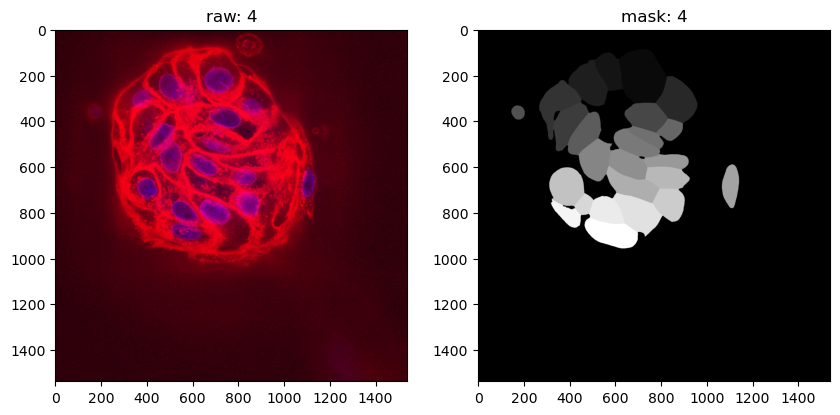

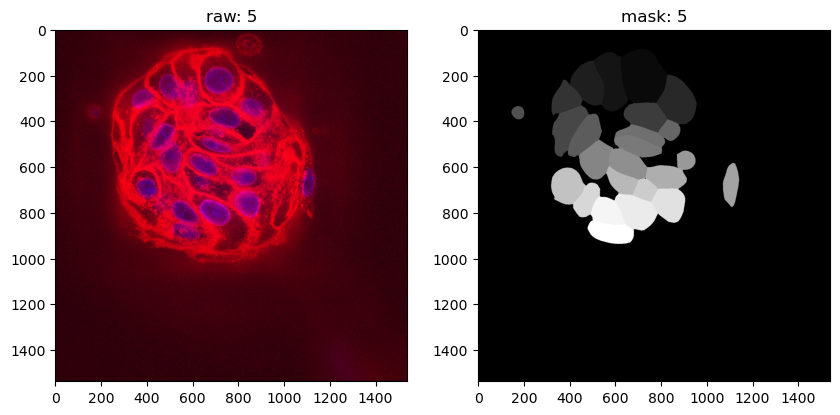

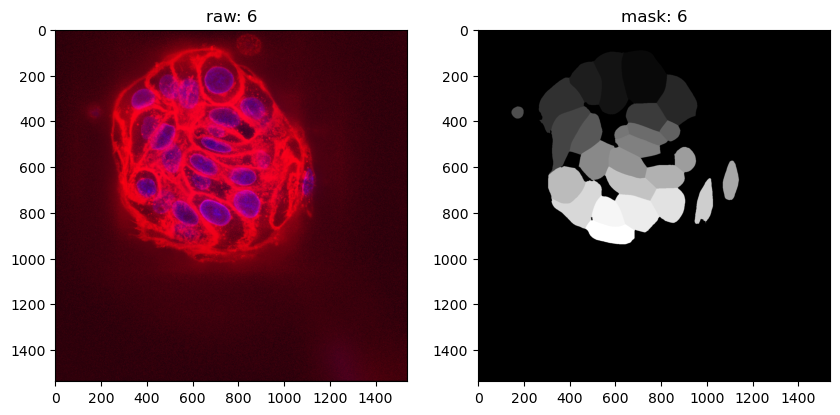

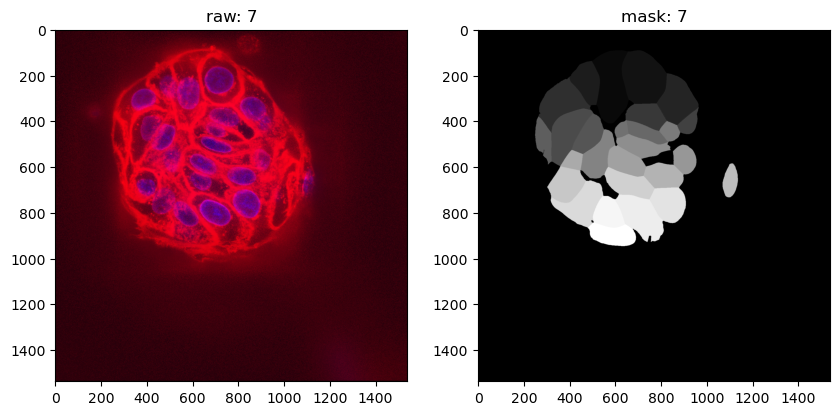

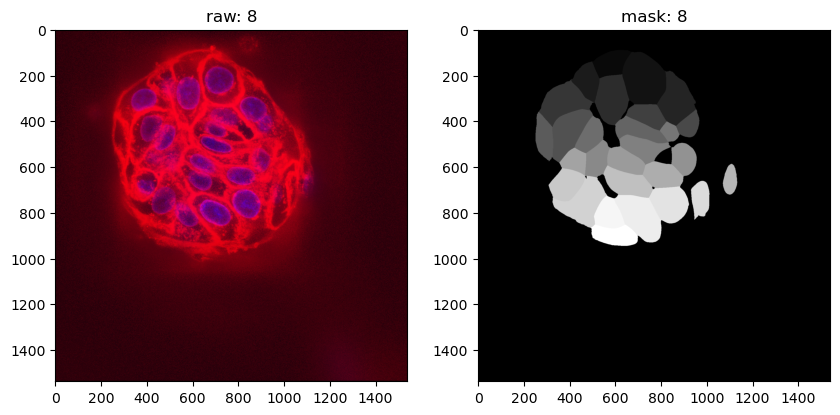

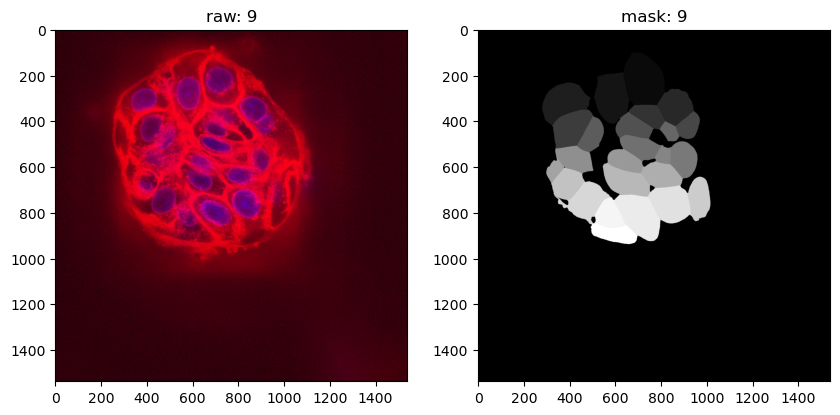

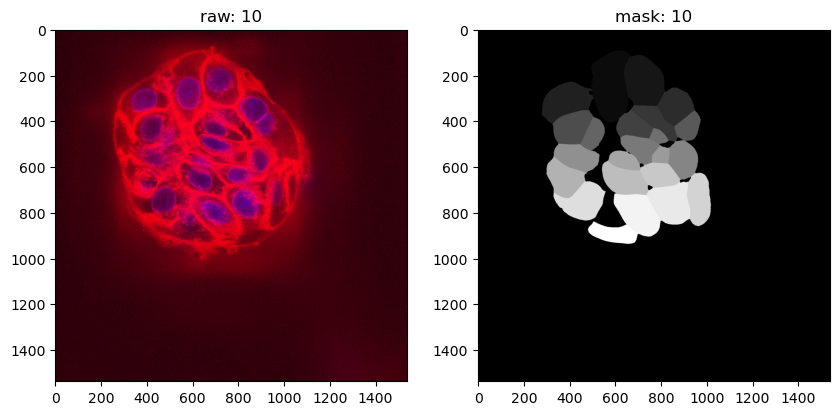

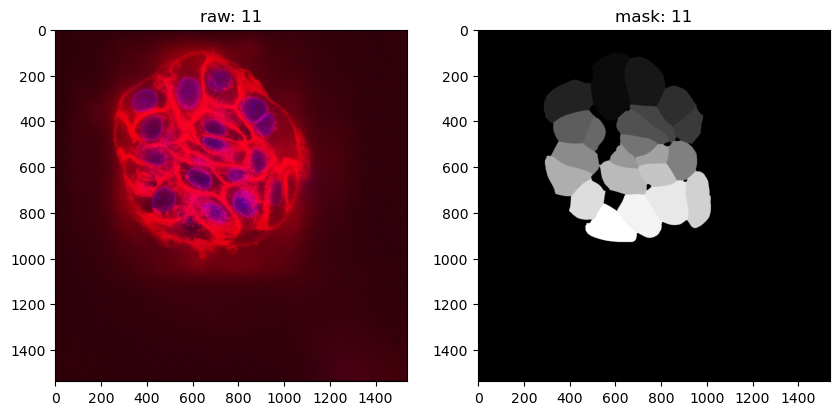

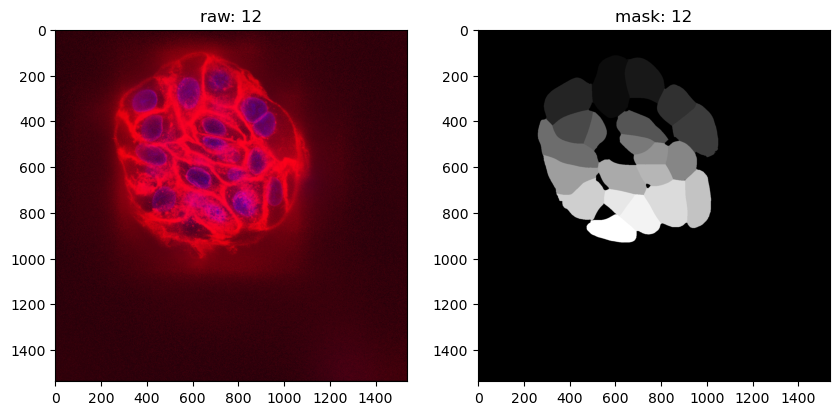

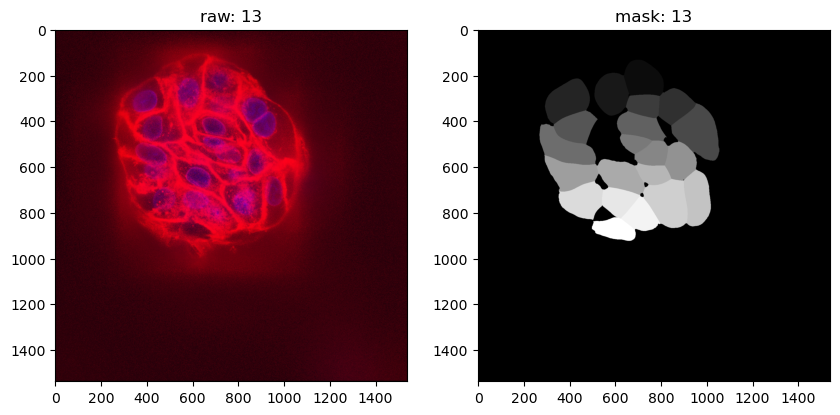

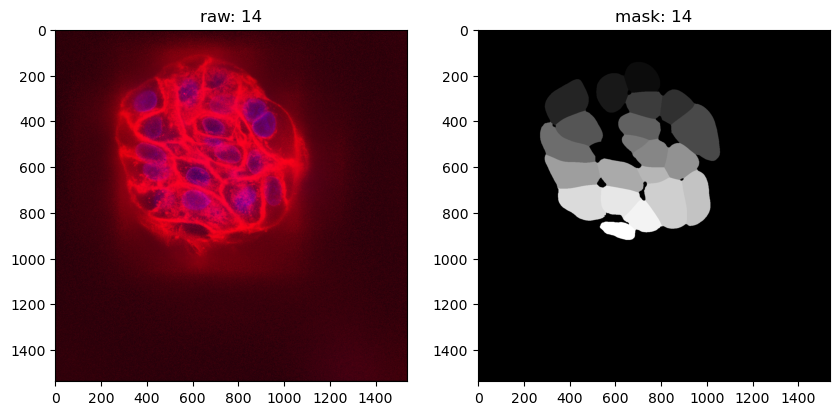

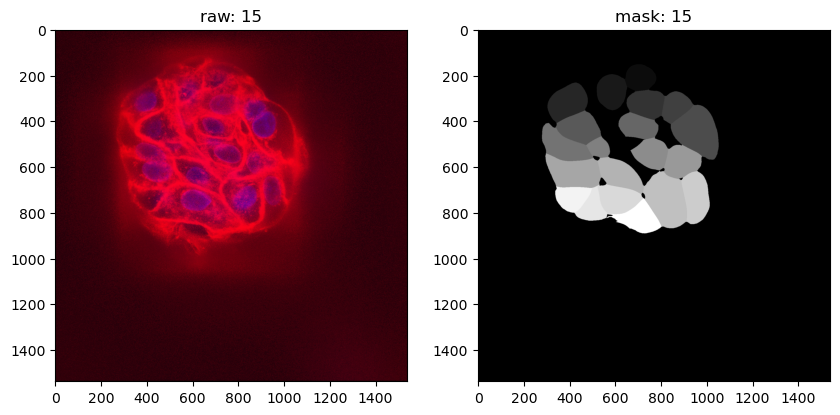

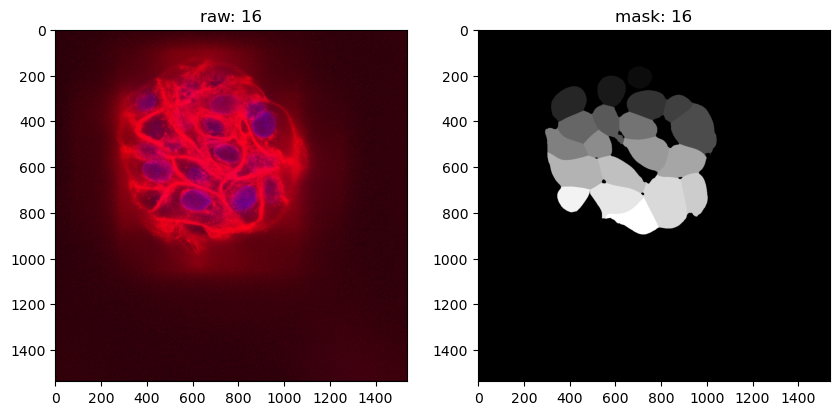

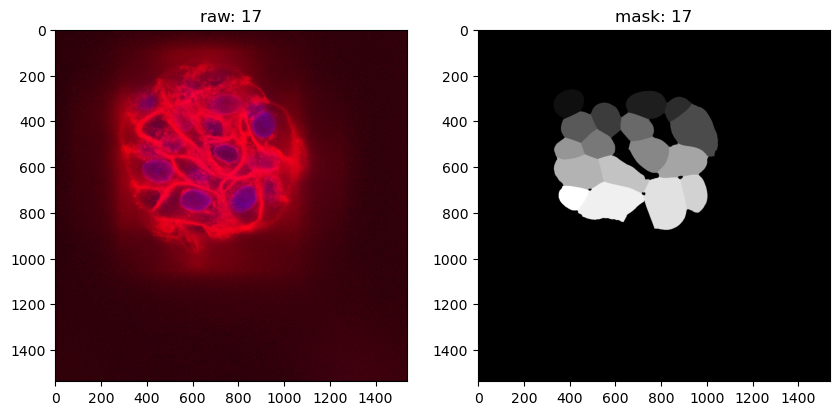

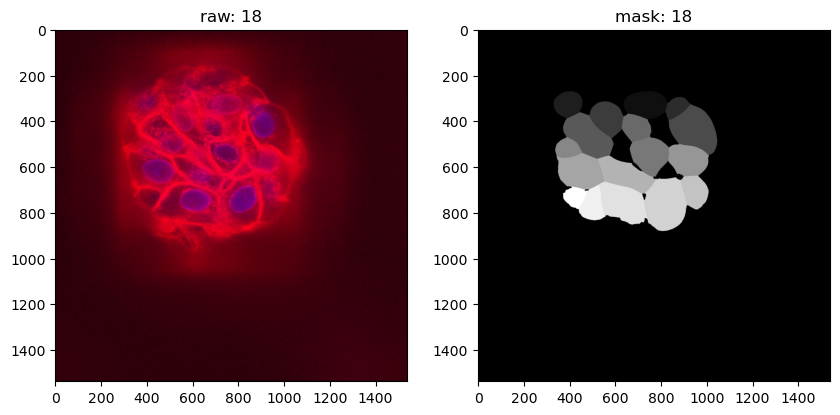

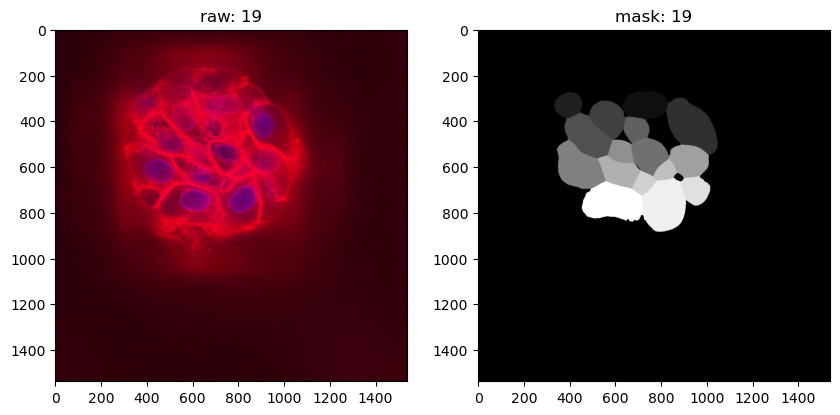

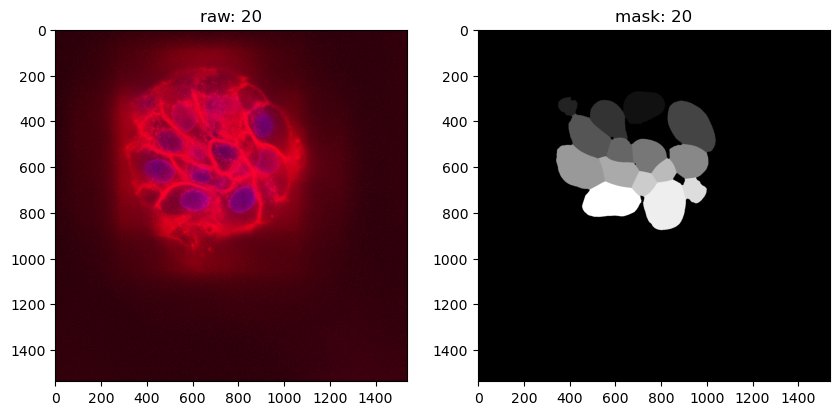

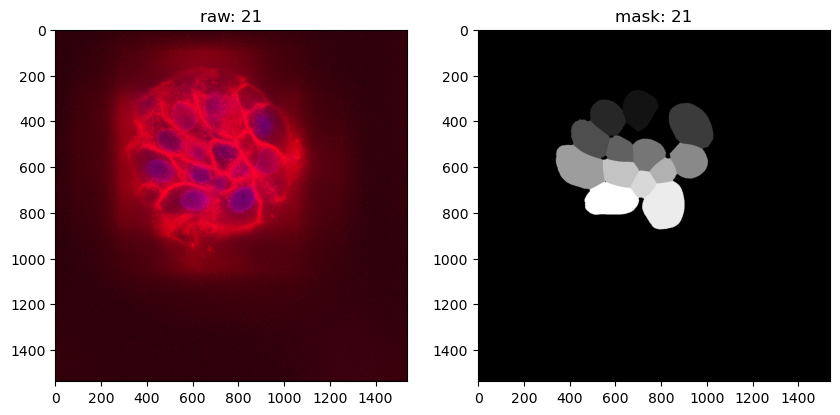

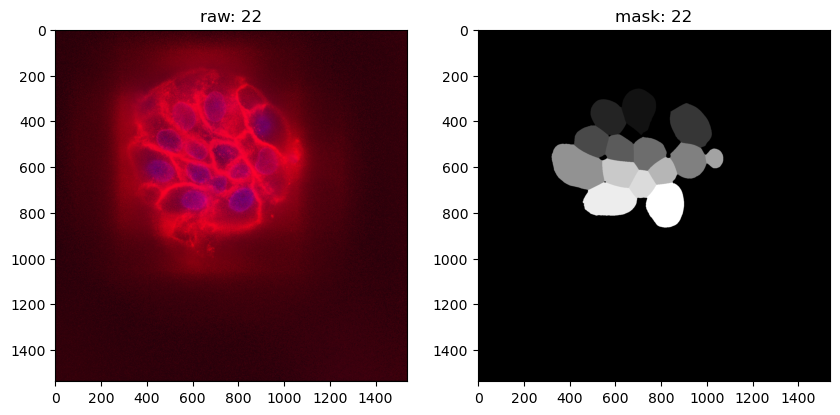

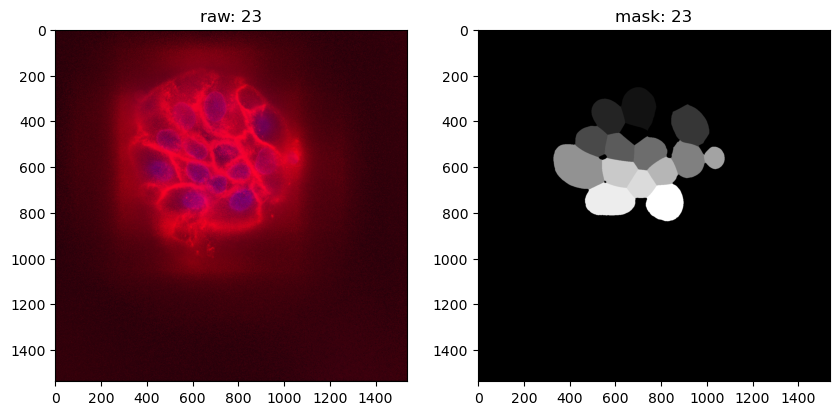

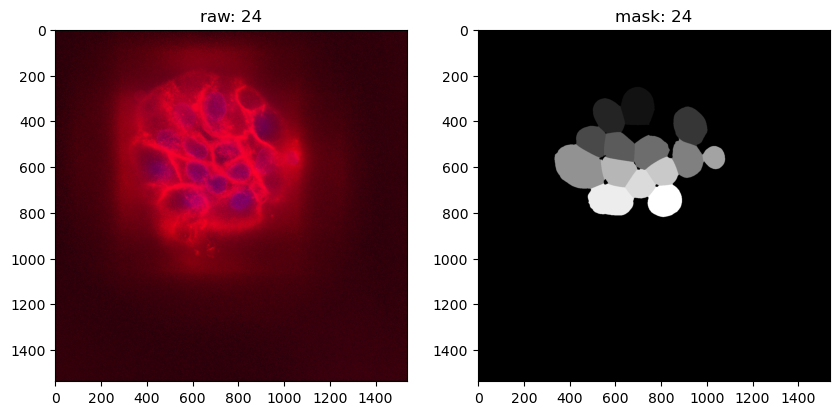

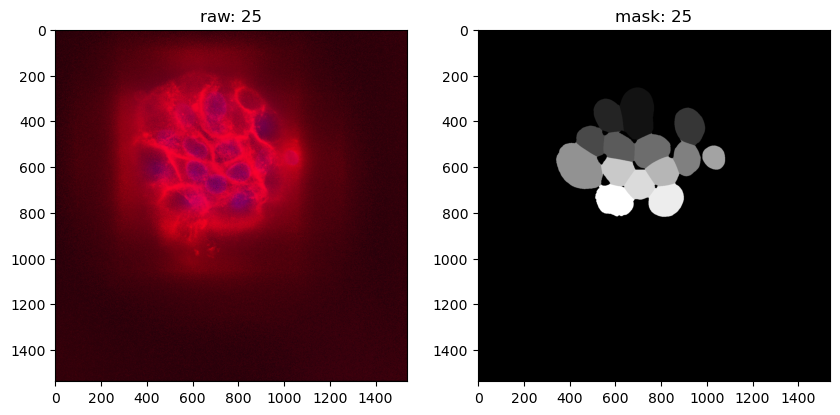

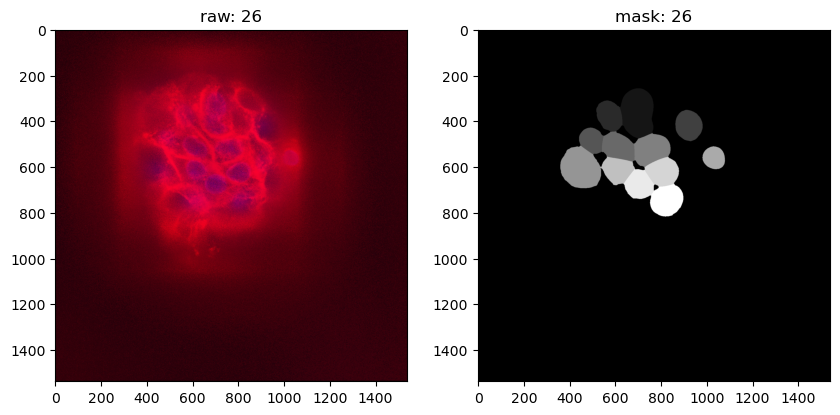

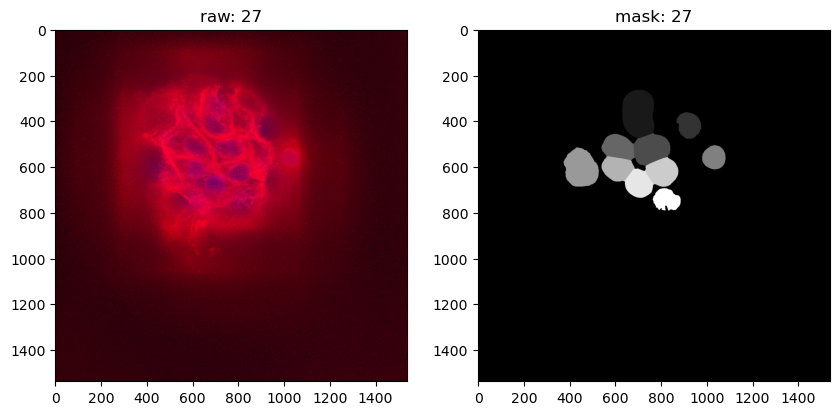

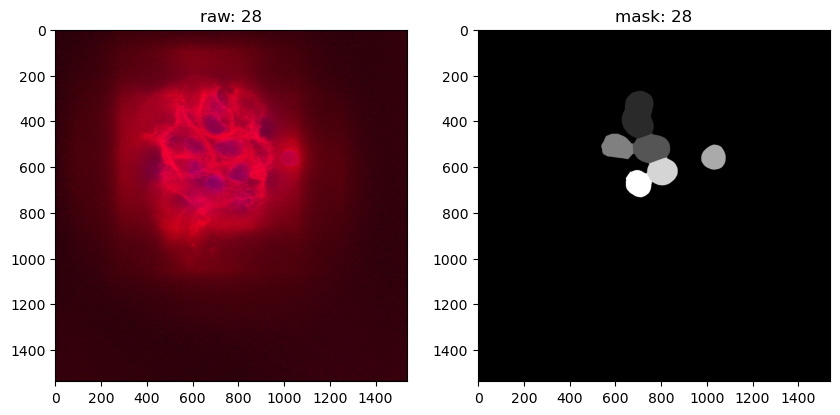

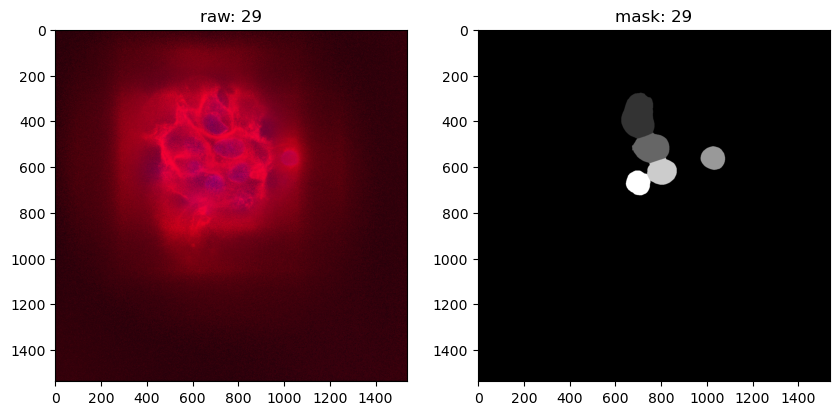

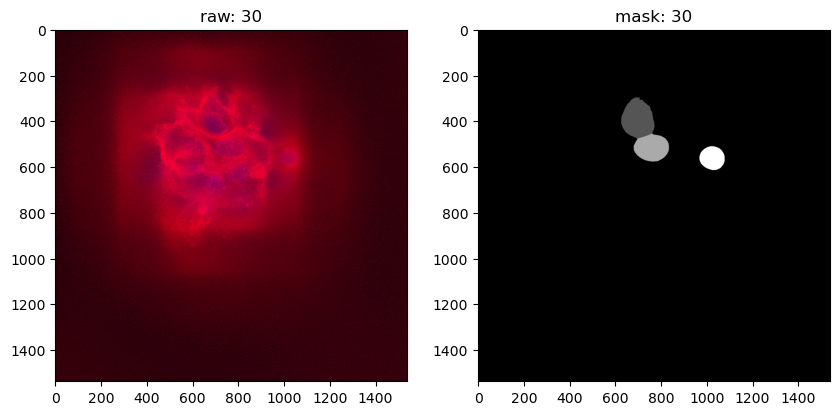

In [11]:
if in_notebook:
    # masks, flows, styles, diams
    plot = plt.figure(figsize=(10, 5))
    for z in range(len(masks_all)):
        plt.figure(figsize=(10, 10))
        plt.subplot(121)
        plt.imshow(imgs[z], cmap="gray")
        plt.title(f"raw: {z}")
        plt.subplot(122)
        plt.imshow(masks_all[z], cmap="gray")
        plt.title(f"mask: {z}")
        plt.show()